In [213]:
# Import required packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#added this to supress warning messages
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "4"



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Phase 2: Data Preprossings and Exploration 

In [216]:
# Read in employee Dataset into variable df
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first few rows of the dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [218]:
##determining if any columns I would like to remove
##Although not all columns are used, they are not necessary hindering data analysis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [220]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [222]:
df.shape

(1470, 35)

In [224]:
#Checking for missing values or duplicate records

print("\nMissing values (total):", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nAttrition value counts:")
print(df["Attrition"].value_counts())


Missing values (total): 0
Duplicate rows: 0

Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [226]:
###Phase 2 — EDA (Exploratory Data Analysis)

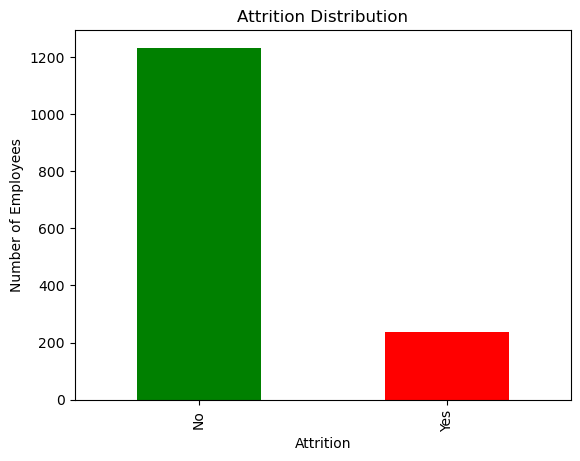

In [228]:
# Plot Attrition distribution
df["Attrition"].value_counts().plot(kind="bar", color=['green', 'red'])
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

In [230]:
# Attrition rate
attr_counts = df["Attrition"].value_counts()
attr_rate = (attr_counts.get("Yes", 0) / len(df)) * 100
print(f"Attrition rate (Yes): {attr_rate:.2f}%")

Attrition rate (Yes): 16.12%


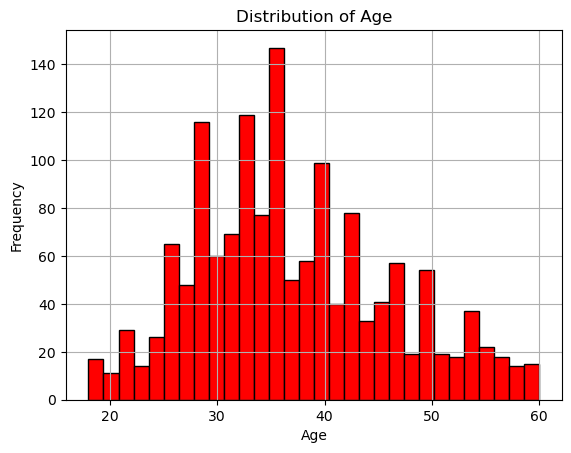

In [233]:
#Next we will see how various catgories affected attrition
# Age distribution - Most attribution takes place in early career
# After Age 40 attrition rates decrease
df["Age"].hist(bins=30, color="red", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()



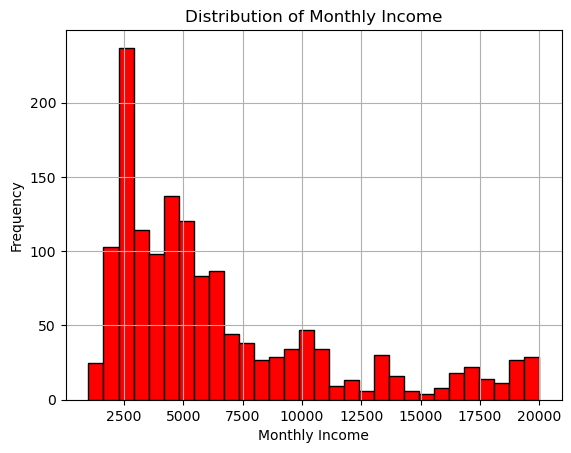

In [235]:
# Monthly Income distribution
#Lower wage workers are more likely to leave the company
df["MonthlyIncome"].hist(bins=30, color="red", edgecolor="black")
plt.title("Distribution of Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

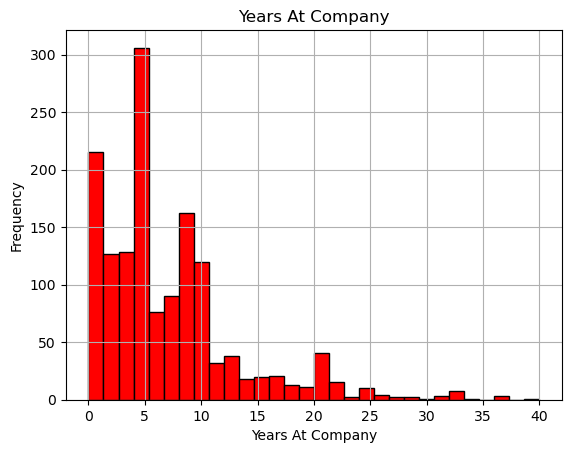

In [237]:
# Years At Company distribution
df["YearsAtCompany"].hist(bins=30, color="red", edgecolor="black")
plt.title("Years At Company")
plt.xlabel("Years At Company")
plt.ylabel("Frequency")
plt.show()

In [239]:
# Calculate attrition rate by JobSatisfaction
attrition_rate = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

attrition_rate

JobSatisfaction
1    22.837370
2    16.428571
3    16.515837
4    11.328976
Name: Attrition, dtype: float64

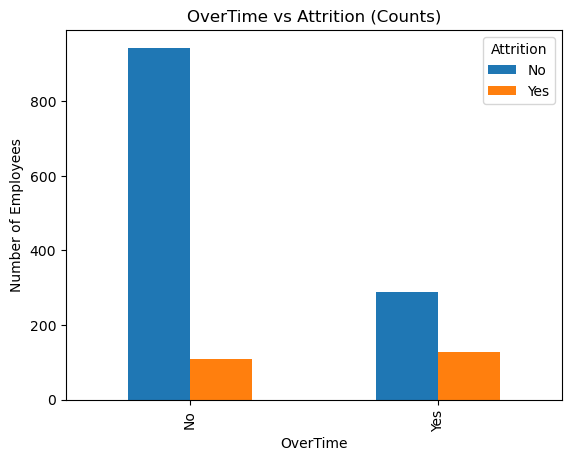

In [241]:
# Visual: OverTime vs Attrition counts
pd.crosstab(df["OverTime"], df["Attrition"]).plot(kind="bar")
plt.title("OverTime vs Attrition (Counts)")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")
plt.show()


In [243]:
# Convert the target column 'Attrition' into numbers:
# Yes -> 1 (left), No -> 0 (stayed)
df["AttritionFlag"] = df["Attrition"].map({"No": 0, "Yes": 1})


feature_cols = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance",
    "OverTime",
    "BusinessTravel",
    "Department",
    "JobRole"
]

X = df[feature_cols]
y = df["AttritionFlag"]

X.head(), y.head()


(   Age  MonthlyIncome  DistanceFromHome  YearsAtCompany  JobSatisfaction  \
 0   41           5993                 1               6                4   
 1   49           5130                 8              10                2   
 2   37           2090                 2               0                3   
 3   33           2909                 3               8                3   
 4   27           3468                 2               2                2   
 
    WorkLifeBalance OverTime     BusinessTravel              Department  \
 0                1      Yes      Travel_Rarely                   Sales   
 1                3       No  Travel_Frequently  Research & Development   
 2                3      Yes      Travel_Rarely  Research & Development   
 3                3      Yes  Travel_Frequently  Research & Development   
 4                3       No      Travel_Rarely  Research & Development   
 
                  JobRole  
 0        Sales Executive  
 1     Research Scientist  


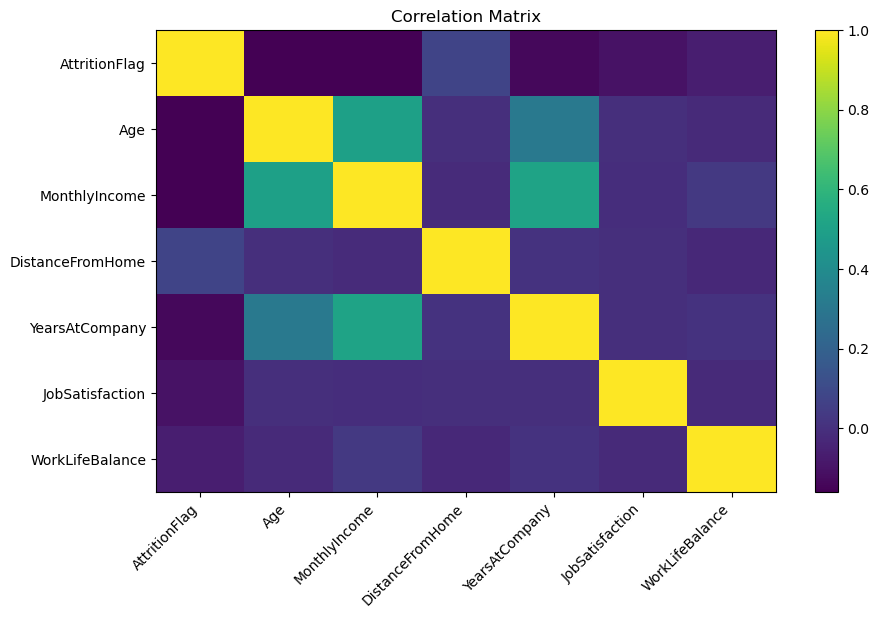

In [154]:
df["AttritionFlag"] = df["Attrition"].map({"No": 0, "Yes": 1})

corr_cols = ["AttritionFlag", "Age", "MonthlyIncome", "DistanceFromHome",
             "YearsAtCompany", "JobSatisfaction", "WorkLifeBalance"]

corr_matrix = df[corr_cols].corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

In [155]:
corr_matrix

,AttritionFlag,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,JobSatisfaction,WorkLifeBalance
AttritionFlag,1.000000,-0.159205,-0.159840,0.077924,-0.134392,-0.103481,-0.063939
Age,-0.159205,1.000000,0.497855,-0.001686,0.311309,-0.004892,-0.021490
MonthlyIncome,-0.159840,0.497855,1.000000,-0.017014,0.514285,-0.007157,0.030683
DistanceFromHome,0.077924,-0.001686,-0.017014,1.000000,0.009508,-0.003669,-0.026556
YearsAtCompany,-0.134392,0.311309,0.514285,0.009508,1.000000,-0.003803,0.012089
JobSatisfaction,-0.103481,-0.004892,-0.007157,-0.003669,-0.003803,1.000000,-0.019459
WorkLifeBalance,-0.063939,-0.021490,0.030683,-0.026556,0.012089,-0.019459,1.000000


In [ ]:
#Model 1 — Logistic Regression (Attrition Prediction)

#Phase 3 — 
#Model 1: Logistic Regression (Predict Attrition)
#The goal of this model is to predict whether an employee will leave the company (Attrition = Yes/No) using employee demographic, job, and satisfaction features.
##Logistic Regression was selected because the target variable (Attrition) is categorical with two classes (Yes/No).
#The goal is to predict employee attrition based on demographic, compensation, and job-related features. 


In [156]:
# Convert categorical columns into numeric "dummy" columns.
# This is required because ML models need numbers.
X_encoded = pd.get_dummies(X, drop_first=True)

# Check the new shape after encoding
X_encoded.shape


(1470, 19)

In [157]:
# Split the data into training and test sets
# Train = used to learn patterns, Test = used to evaluate how well we predict new data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((1102, 19), (368, 19))

In [158]:
# Scale (standardize) the features so they are on a similar range.
# This helps Logistic Regression perform better.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [160]:
#Model 1 — Logistic Regression (Attrition Prediction)

In [161]:
# Train logistic regression model
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = log_model.predict(X_test_scaled)

# Evaluation metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

cm, acc, prec, rec, f1

(array([[305,   4],
        [ 45,  14]], dtype=int64),
 0.8668478260869565,
 0.7777777777777778,
 0.23728813559322035,
 0.36363636363636365)

In [162]:
# Look at the most important features using model coefficients
# Larger absolute value = stronger relationship with attrition in this model.
coef_df = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Top 10 strongest features
coef_df.sort_values("AbsCoefficient", ascending=False).head(10)


,Feature,Coefficient,AbsCoefficient
12,JobRole_Laboratory Technician,0.694268,0.694268
6,OverTime_Yes,0.682394,0.682394
7,BusinessTravel_Travel_Frequently,0.540033,0.540033
0,Age,-0.467035,0.467035
18,JobRole_Sales Representative,0.434342,0.434342
17,JobRole_Sales Executive,0.407448,0.407448
3,YearsAtCompany,-0.403847,0.403847
11,JobRole_Human Resources,0.368558,0.368558
4,JobSatisfaction,-0.335061,0.335061
10,Department_Sales,0.333910,0.333910


#Phase 3 — Model 2: KMeans Clustering 

In [164]:
# Select a simple set of numeric features for clustering
cluster_cols = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "YearsAtCompany",
    "JobSatisfaction",
    "WorkLifeBalance"
]

X_cluster = df[cluster_cols]

# Standardize for clustering
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Try a few K values WITHOUT a loop (beginner-friendly)
k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = k2.fit_predict(X_cluster_scaled)
sil2 = silhouette_score(X_cluster_scaled, labels2)

k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = k3.fit_predict(X_cluster_scaled)
sil3 = silhouette_score(X_cluster_scaled, labels3)

k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels4 = k4.fit_predict(X_cluster_scaled)
sil4 = silhouette_score(X_cluster_scaled, labels4)

sil2, sil3, sil4

print("Silhouette Scores:")
print("K=2:", sil2)
print("K=3:", sil3)
print("K=4:", sil4)



Silhouette Scores:
K=2: 0.2804702698725306
K=3: 0.18357408800399577
K=4: 0.1915020772583713


In [165]:
# Pick the best K from the silhouette scores above.
# (Higher silhouette score is generally better.)
# For this notebook, we will use K=3 as a common, interpretable choice.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

df["Cluster"].value_counts().sort_index()

Cluster
0    469
1    251
2    750
Name: count, dtype: int64

In [166]:
# Understand what each cluster looks like by checking averages
df.groupby("Cluster")[["Age","MonthlyIncome","DistanceFromHome","YearsAtCompany","JobSatisfaction","WorkLifeBalance"]].mean()


,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,JobSatisfaction,WorkLifeBalance
Cluster,,,,,,
0,34.618337,4787.449893,9.189765,5.347548,1.479744,2.771855
1,47.478088,14767.043825,8.557769,14.621514,2.697211,2.737052
2,34.833333,4809.956000,9.406667,5.498667,3.520000,2.762667


In [167]:
# Attrition rate by cluster (this shows which cluster is most at risk)
pd.crosstab(df["Cluster"], df["Attrition"], normalize="index")


Attrition,No,Yes
Cluster,,
0,0.778252,0.221748
1,0.932271,0.067729
2,0.845333,0.154667


In [168]:
print("Model Evaluation Summary")
print("------------------------")
print("Logistic Regression:")
print(f"  Accuracy : {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-score : {f1:.4f}")


Model Evaluation Summary
------------------------
Logistic Regression:
  Accuracy : 0.8668
  Precision: 0.7778
  Recall   : 0.2373
  F1-score : 0.3636


In [169]:
#Phase 4

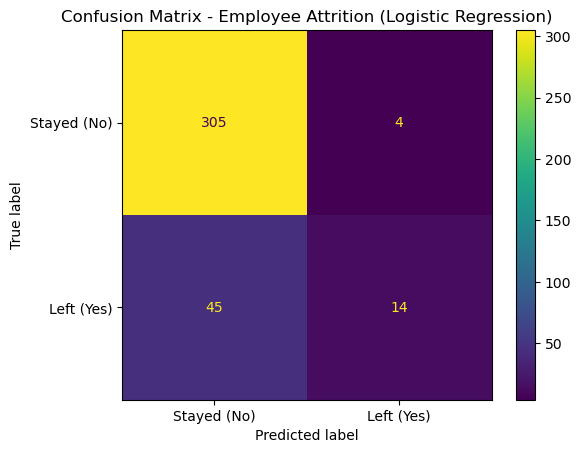

In [170]:
cm = confusion_matrix(y_test, y_pred)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed (No)", "Left (Yes)"]
)

disp.plot()
plt.title("Confusion Matrix - Employee Attrition (Logistic Regression)")
plt.show()

In [171]:
###Phase 5: Deployment and Insights 

Logistic Regression performed best for the main problem because it directly predicts Attrition (a Yes/No outcome) and provides classification metrics like accuracy, precision, recall, and F1-score. KMeans clustering was still useful, but it does not predict Attrition; instead, it groups employees into segments that HR can target with different retention strategies. Therefore, Logistic Regression is the strongest model for prediction, and clustering is best for employee segmentation.

In [173]:

#Deployment
#1. HR exports the latest employee data (weekly/monthly)
#2. The preprocessing + logistic regression pipeline scores each employee's risk
#3. HR reviews the highest-risk employees (human decision-making stays involved)
#4. Track model performance over time and retrain when needed

#Insights:

#1. If OverTime employees have much higher attrition, consider workload changes or pay adjustments.
#2. Put procedures in place to ensure employees nearly 5 years of service are seen and feel needed. 